<a href="https://colab.research.google.com/github/fridayunuen/Datacamp/blob/feature%2Fapplied_statistics_in_python/experimental_design_in_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

------
# 🔬 **Experimental Design Preliminaries**

## **🔬 Setting up experiments**

**Settings**

In [23]:
# Imports
import pandas as pd

# Data
chick_weight = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datacamp/Applied Statistics in Python/Experimental Design in Python/data/chick_weight.csv')

# Utils
def highlight_mean(row):
    if row.name == 'mean':
        return ['background-color: yellow'] * len(row)
    else:
        return [''] * len(row)

def compare_groups(group1, group2):
    compare_df = pd.concat([group1.describe(), group2.describe()], axis=1)
    compare_df.columns = [f"group1", f"group2"]
    return compare_df.style.apply(highlight_mean, axis=1)



Experimental designs is the process in which we carry out research in a objetive and controlled fashion. The purposed of this is to ensure we can make specific conclusions in reference to a hypothesis we have.

**Forming robust statements**

Because we use objetive tools, we need to used quantified language.

❌ X **probably** had an effect on Y. There is **likely** some **small** risk of error

✅ P-value analysis indicates **X had an effect** on Y with a 10% **risk type I error**

- Type I error: incorrectly reject null hypothesis

**Some terminology…**

- **Subjects**: what we are experimenting on (people, employees, users, etc…)
- **Treatment**: some change given to one group
- **Control**: the group not given any change


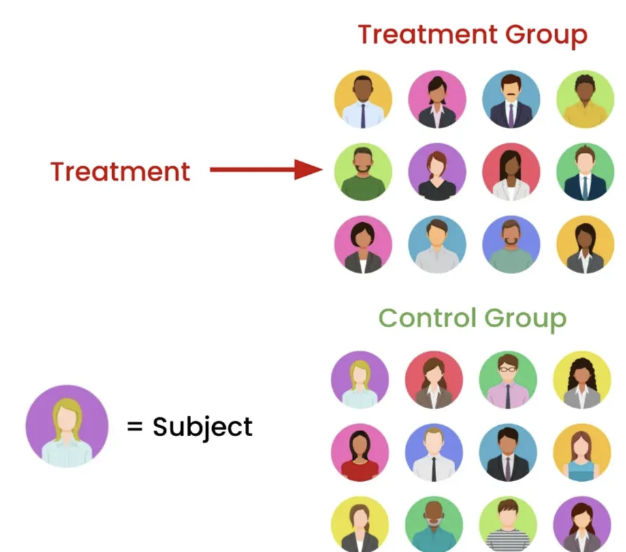

### **Assigning subjects to groups**

1. Non-randomly (”split” the data frame). We could just split the datset non-randomly into chunks and assign each chunk to a group
2. Use random assignment to sample into our desired group

In [56]:
weight = chick_weight["weight"]

Very different mean!
Because of the difference in these groups, it will be harder to confidently determine if any changes are due to the treatment invervention!

In [57]:
group1_no_random = weight.iloc[0:250,]
group2_no_random = weight.iloc[250:,]

compare_groups(group1_no_random, group2_no_random)

,group1,group2
count,250.000000,328.000000
mean,105.876000,133.969512
std,61.548791,75.405361
min,35.000000,39.000000
25%,58.250000,68.000000
50%,89.000000,123.000000
75%,138.750000,184.000000
max,331.000000,373.000000


Using the same comparison method we se much closer means!

In [58]:
group1 = weight.sample(frac=0.5,
                       replace=False, # samples aren't selected twice
                       random_state=42)
group2 = weight.drop(group1.index)

compare_groups(group1, group2)

,group1,group2
count,289.000000,289.000000
mean,120.044983,123.591696
std,70.089685,72.118725
min,35.000000,39.000000
25%,62.000000,63.000000
50%,105.000000,103.000000
75%,163.000000,164.000000
max,373.000000,361.000000


* Subjects should be __randomly__ assigned to groups
* Observe changes correctly attributed

-----
## **🔬Experimental data setup**

### The problem with randomization

1. Uneven issue: different number of subjects in groups

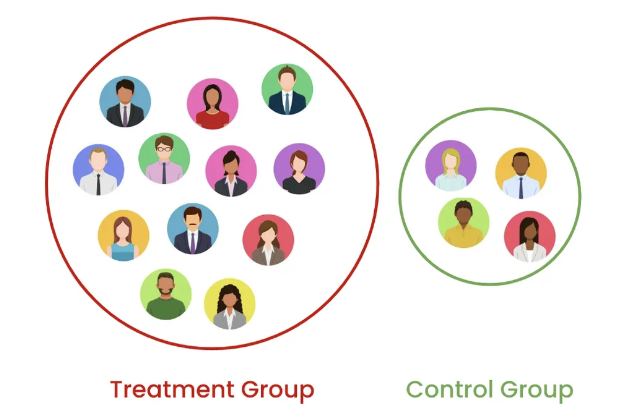

1. **Covariate issue**: High variability in some covariates → group imbalances in randomization. If covariates are highly variable or not equally **distributed** among groups, randomization may not produce balanced groups. This lead to biased results. Overall these make it harder to see an effect from a treatment, as these issues may be driving an observed change

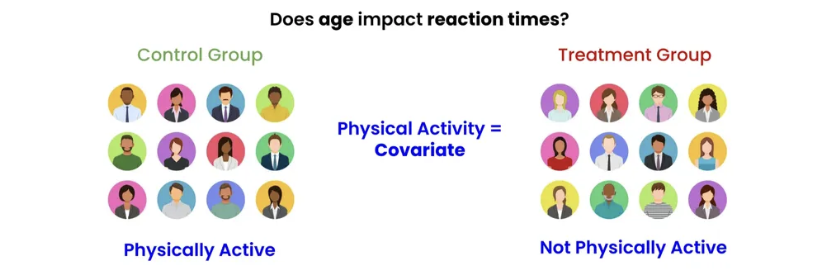

**Block randomization**

This involves splitting into a block of size n first then randomly splitting.

Subjects are split into two groups, then randomly assigned to be Treatment (orange) or control (white).

This fixes uneven issue, and the smaller blocks give us more control over the allocation

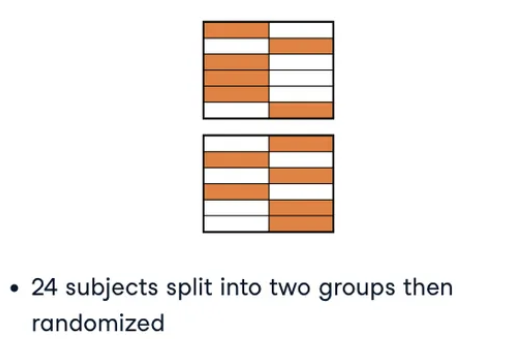